In [ ]:
# [Librerías importadas]

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import rioxarray
from shapely.geometry import Point
import warnings
import tempfile
warnings.filterwarnings("ignore")

In [67]:

def mapa_climatico_anual(
    rutas: dict,
    shapefile_path: str,
    variable_nc: str,
    nombre_columna: str,
    etiqueta_colorbar: str,
    titulo_general: str,
    unidad_conversion=None,
    cmap: str = "YlGnBu",
    vecinos: int = 3,
    guardar_raster: bool = False,
    carpeta_salida: str = "resultados"
):
    """
    Genera mapas anuales promedio por municipio para una variable climática
    (clasificación por cuantiles k=5), rellena valores faltantes por vecinos
    y guarda automáticamente un CSV con los promedios anuales.
    """

    # ------------------------------------------------------------
    # 1️⃣ Cargar shapefile base (filtrar Atlántico)
    # ------------------------------------------------------------
    gdf_base = gpd.read_file(shapefile_path, encoding="utf-8")
    if "mpio_cnmbr" in gdf_base.columns:
        gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
    gdf_base = gdf_base[gdf_base['dpto_cnmbr'].str.upper() == 'ATLÁNTICO']

    resultados = []

    # ------------------------------------------------------------
    # 2️⃣ Crear figura
    # ------------------------------------------------------------
    n = len(rutas)
    filas = 2
    columnas = int(np.ceil(n / filas))
    fig, axes = plt.subplots(filas, columnas, figsize=(4 * columnas, 4 * filas))
    axes = axes.flatten()

    # ------------------------------------------------------------
    # 3️⃣ Procesar cada año
    # ------------------------------------------------------------
    for i, (anio, ruta) in enumerate(rutas.items()):
        print(f"📆 Procesando {anio}...")

        ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")
        var = ds[variable_nc].rio.write_crs("EPSG:4326")

        # --- Conversión automática ---
        data = var
        if "Temperature" in variable_nc:
            data = data - 273.15  # Kelvin → °C
            if cmap == "YlGnBu":
                cmap = "RdYlBu_r"
        elif "Humidity" in variable_nc or "Humedad" in variable_nc:
            if data.max() <= 1:
                data = data * 100  # 0–1 → %
            cmap = "YlGnBu"

        # --- Conversión personalizada ---
        if unidad_conversion is not None:
            data = unidad_conversion(data)

        # --- Promedio anual ---
        promedio_anual = data.mean(dim="time", skipna=True)

        # --- Guardar raster temporal ---
        if guardar_raster and carpeta_salida:
            os.makedirs(carpeta_salida, exist_ok=True)
            raster_out = os.path.join(carpeta_salida, f"{nombre_columna}_{anio}.tif")
            promedio_anual.rio.to_raster(raster_out)
        else:
            tmp = tempfile.NamedTemporaryFile(suffix=".tif", delete=False)
            raster_out = tmp.name
            promedio_anual.rio.to_raster(raster_out)
            tmp.close()

        # --- Estadísticas zonales ---
        gdf = gdf_base.copy()
        stats = zonal_stats(gdf, raster_out, stats="mean", nodata=np.nan)
        gdf[nombre_columna] = [s["mean"] for s in stats]

        # --- Rellenar faltantes con promedio de vecinos ---
        gdf["centroide"] = gdf.geometry.centroid
        gdf_con_datos = gdf.dropna(subset=[nombre_columna])
        gdf_sin_datos = gdf[gdf[nombre_columna].isna()]

        for idx, row in gdf_sin_datos.iterrows():
            gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
            vecinos_cercanos = gdf_con_datos.nsmallest(vecinos, "dist")
            gdf.at[idx, nombre_columna] = vecinos_cercanos[nombre_columna].mean()

        gdf.drop(columns="centroide", inplace=True)

        # --- Guardar resultado para CSV ---
        gdf["año"] = anio
        resultados.append(gdf[["municipio", "año", nombre_columna]])

        # --- Graficar ---
        ax = axes[i]
        gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
        gdf.plot(
            column=nombre_columna,
            cmap=cmap,
            scheme="Quantiles",
            k=5,
            edgecolor="black",
            linewidth=0.5,
            ax=ax,
            missing_kwds={"color": "white", "hatch": "///", "label": "Sin datos"}
        )

        sm = plt.cm.ScalarMappable(
            cmap=cmap,
            norm=plt.Normalize(vmin=gdf[nombre_columna].min(), vmax=gdf[nombre_columna].max())
        )
        sm._A = []
        cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
        cbar.set_label(etiqueta_colorbar, fontsize=9)

        ax.set_title(f"{anio}", fontsize=11)
        ax.axis("off")

        # Limpiar archivo temporal
        if not guardar_raster:
            os.remove(raster_out)

    # ------------------------------------------------------------
    # 4️⃣ Guardar CSV final
    # ------------------------------------------------------------
    df_final = pd.concat(resultados, ignore_index=True)
    os.makedirs(carpeta_salida, exist_ok=True)
    csv_path = os.path.join(carpeta_salida, f"{nombre_columna}_anual.csv")
    df_final.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"✅ CSV guardado: {csv_path}")

    # ------------------------------------------------------------
    # 5️⃣ Mostrar figura final
    # ------------------------------------------------------------
    plt.suptitle(titulo_general, fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    return df_final


## Precipitación

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\precipitacion_anual.csv


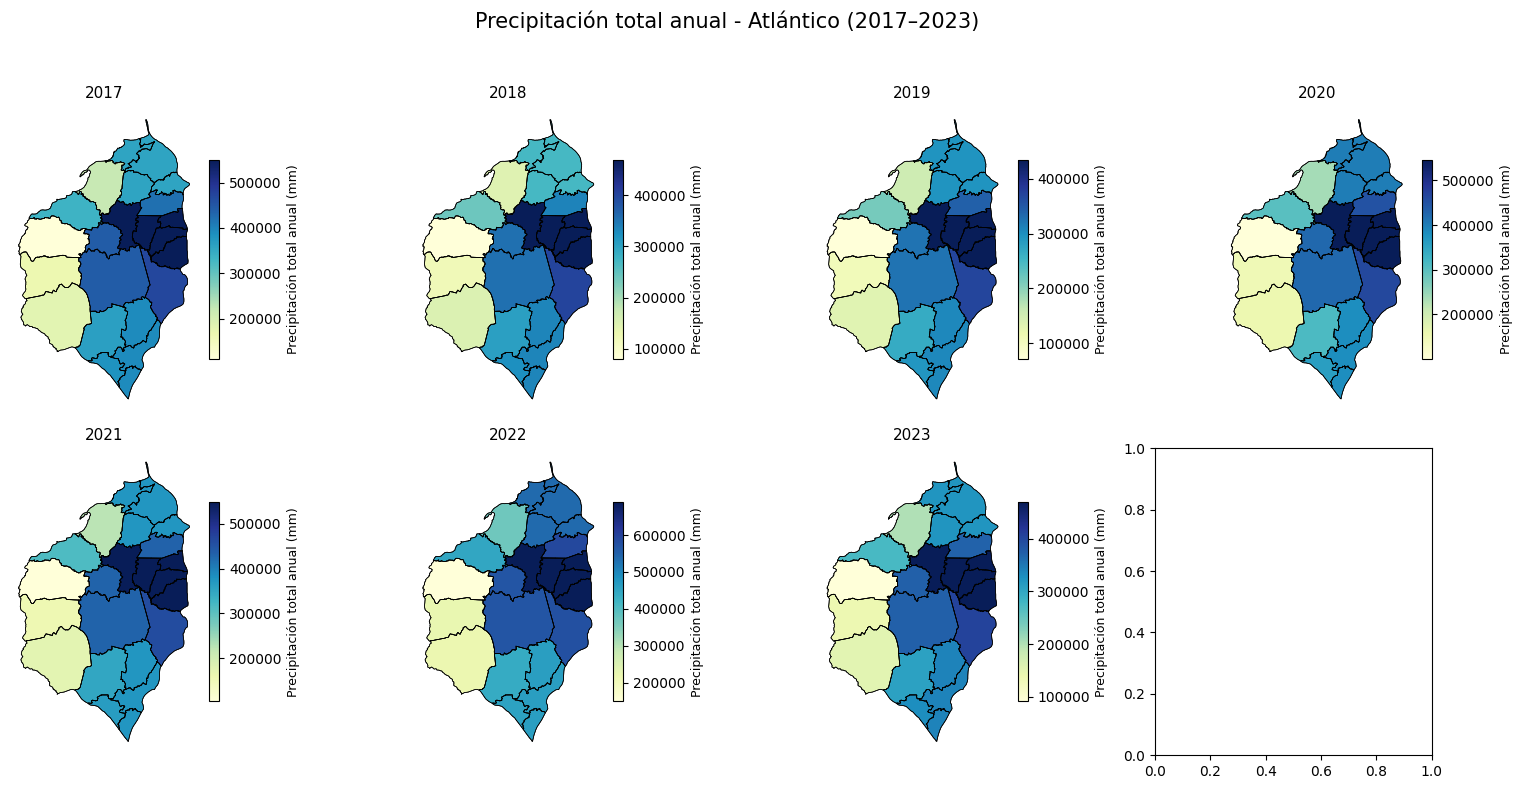

In [66]:
rutas_prec = {
   
    2017: r"C:\Dengue\Datos Clima\precipitacion_atl_2017",
    2018: r"C:\Dengue\Datos Clima\precipitacion_atl_2018",
    2019: r"C:\Dengue\Datos Clima\precipitacion_atl_2019",
    2020: r"C:\Dengue\Datos Clima\precipitacion_atl_2020",
    2021: r"C:\Dengue\Datos Clima\precipitacion_atl_2021",
    2022: r"C:\Dengue\Datos Clima\precipitacion_atl_2022",
    2023: r"C:\Dengue\Datos Clima\precipitacion_atl_2023"
}


df_precipitacion = mapa_climatico_anual(
    rutas=rutas_prec,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Precipitation_Flux",
    nombre_columna="precipitacion",
    etiqueta_colorbar="Precipitación total anual (mm)",
    titulo_general="Precipitación total anual - Atlántico (2017–2023)",
    # conversión de kg/m²/s a mm/día, si tus datos vienen en flujo
    unidad_conversion=lambda x: x * 86400,
    carpeta_salida="resultados"
)



## Humedad Relativa

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\humedad_anual.csv


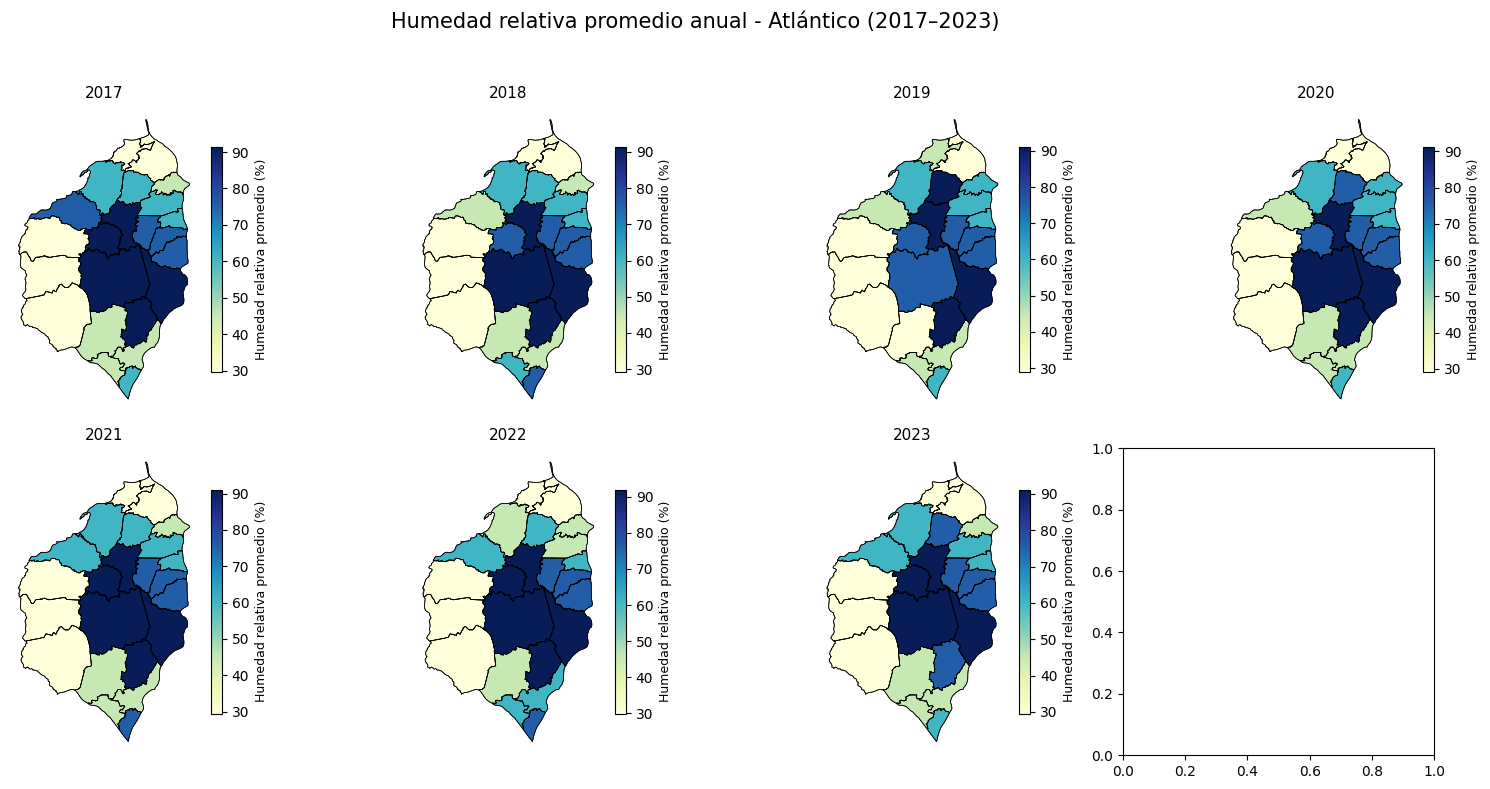

In [68]:
rutas_hum = {
    2017: r"C:\Dengue\Datos Clima\humedad_atl_2017",
    2018: r"C:\Dengue\Datos Clima\humedad_atl_2018",
    2019: r"C:\Dengue\Datos Clima\humedad_atl_2019",
    2020: r"C:\Dengue\Datos Clima\humedad_atl_2020",
    2021: r"C:\Dengue\Datos Clima\humedad_atl_2021",
    2022: r"C:\Dengue\Datos Clima\humedad_atl_2022",
    2023: r"C:\Dengue\Datos Clima\humedad_atl_2023"
}

df_humedad = mapa_climatico_anual(
    rutas=rutas_hum,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Relative_Humidity_2m_06h",
    nombre_columna="humedad",
    etiqueta_colorbar="Humedad relativa promedio (%)",
    titulo_general="Humedad relativa promedio anual - Atlántico (2017–2023)",
    unidad_conversion=None,
    carpeta_salida="resultados"
)



## Temperatura

### Maxima

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\temp_max_anual.csv


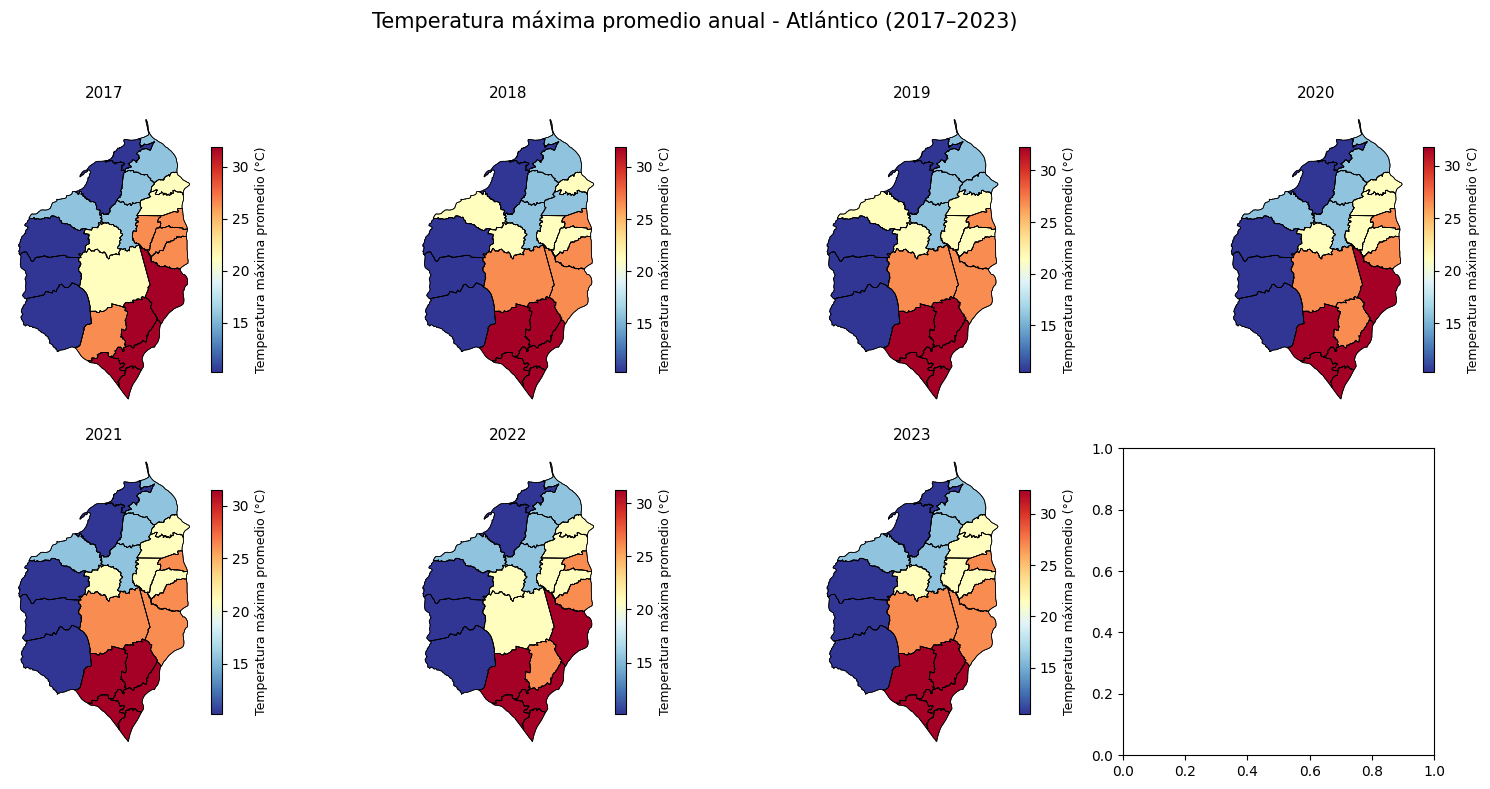

In [69]:
rutas_temp_max = {
    2017: r"C:\Dengue\Datos Clima\temp_max_atl_2017",
    2018: r"C:\Dengue\Datos Clima\temp_max_atl_2018",
    2019: r"C:\Dengue\Datos Clima\temp_max_atl_2019",
    2020: r"C:\Dengue\Datos Clima\temp_max_atl_2020",
    2021: r"C:\Dengue\Datos Clima\temp_max_atl_2021",
    2022: r"C:\Dengue\Datos Clima\temp_max_atl_2022",
    2023: r"C:\Dengue\Datos Clima\temp_max_atl_2023"
}
df_tmax = mapa_climatico_anual(
    rutas=rutas_temp_max,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Max_24h",
    nombre_columna="temp_max",
    etiqueta_colorbar="Temperatura máxima promedio (°C)",
    titulo_general="Temperatura máxima promedio anual - Atlántico (2017–2023)",
    unidad_conversion=None,  # ya se convierte automáticamente
    carpeta_salida="resultados"
)


### Minima

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\temp_min_anual.csv


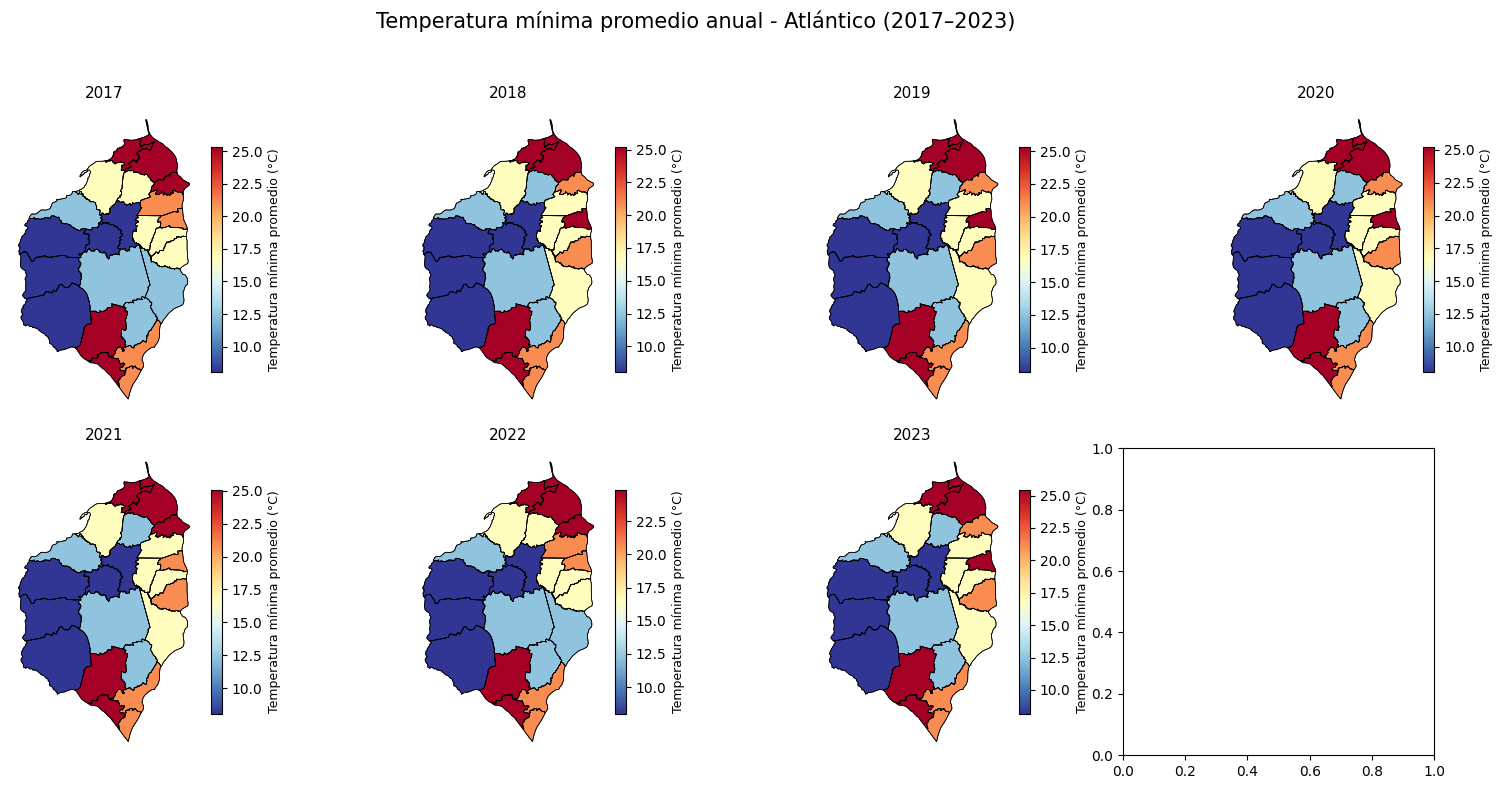

In [70]:
rutas_temp_min = {
    2017: r"C:\Dengue\Datos Clima\temp_min_atl_2017",
    2018: r"C:\Dengue\Datos Clima\temp_min_atl_2018",
    2019: r"C:\Dengue\Datos Clima\temp_min_atl_2019",
    2020: r"C:\Dengue\Datos Clima\temp_min_atl_2020",
    2021: r"C:\Dengue\Datos Clima\temp_min_atl_2021",
    2022: r"C:\Dengue\Datos Clima\temp_min_atl_2022",
    2023: r"C:\Dengue\Datos Clima\temp_min_atl_2023"
}

df_tmin = mapa_climatico_anual(
    rutas=rutas_temp_min,  # diccionario con las rutas de los archivos .nc por año
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Min_24h",
    nombre_columna="temp_min",
    etiqueta_colorbar="Temperatura mínima promedio (°C)",
    titulo_general="Temperatura mínima promedio anual - Atlántico (2017–2023)",
    unidad_conversion=None,
    carpeta_salida="resultados"
)



## Distancia al río mas cercano

In [55]:
gdf_mpios = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_rio.shp")
gdf_mpios.columns

Index(['dpto_ccdgo', 'mpio_ccdgo', 'mpio_cdpmp', 'dpto_cnmbr', 'mpio_cnmbr',
       'mpio_crslc', 'mpio_tipo', 'mpio_narea', 'mpio_nano', 'shape_Leng',
       'shape_Area', 'dist_rio_m', 'dist_rio_1', 'geometry'],
      dtype='object')

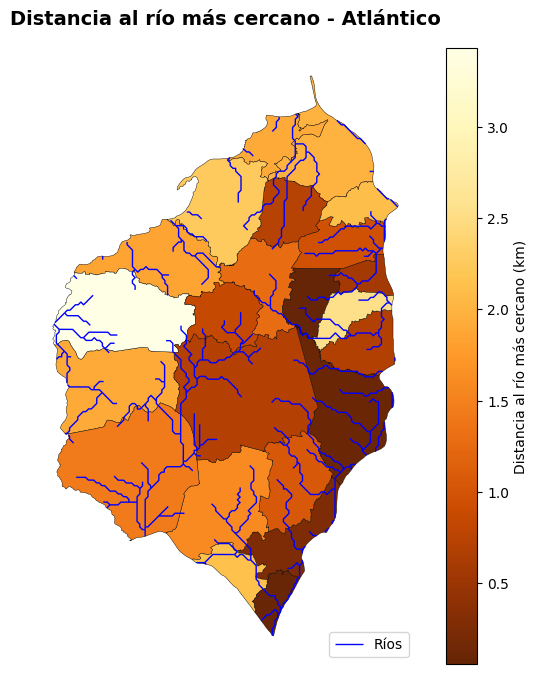

In [57]:
gdf_mpios = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_rio.shp")
rios_clip = gpd.read_file(r"C:\Dengue\Datos Clima\HydroRIVERS_Atlantico.shp")

# --- Asegurar CRS proyectado (para medir en metros) ---
gdf_mpios = gdf_mpios.to_crs(3116)  # EPSG:3116 = Colombia Bogotá / MAGNA-SIRGAS
rios_clip = rios_clip.to_crs(3116)

# --- Crear figura y eje ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- Graficar municipios con la distancia al río ---
gdf_mpios.plot(
    column='dist_rio_1',
    cmap='YlOrBr_r',  # escala invertida: oscuro = más cerca
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': "Distancia al río más cercano (km)",
        'orientation': "vertical"
    },
    ax=ax
)

# --- Graficar ríos encima ---
rios_clip.plot(ax=ax, color='blue', linewidth=1, label='Ríos')

# --- Personalizar ---
ax.set_title("Distancia al río más cercano - Atlántico", fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(loc='lower right')

plt.show()


## Distancia al cuerpo de agua más cercano

In [74]:
municipios_utm = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_lago.shp").to_crs(3116)

municipios_utm.head()

,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,dist_lago_,dist_lag_1,geometry
0,08,001,08001,ATLÁNTICO,BARRANQUILLA,Ordenanza 30 del 5 de Mayo de 1913 Ley 44 del ...,MUNICIPIO,154.285925,2024,0.817698,0.012760,5885.683694,5.885684,"POLYGON ((915660.54 1719159.135, 915668.936 17..."
1,08,078,08078,ATLÁNTICO,BARANOA,Ordenanza 11 del 23 de Octubre de 1856,MUNICIPIO,121.350425,2024,0.729312,0.010029,17603.674854,17.603675,"POLYGON ((905165.933 1692708.018, 905191.115 1..."
2,08,137,08137,ATLÁNTICO,CAMPO DE LA CRUZ,Ordenanza 34 del 16 de Abril de 1914,MUNICIPIO,99.995006,2024,0.653301,0.008254,5433.398254,5.433398,"POLYGON ((919896.686 1651498.44, 920006.18 165..."
3,08,141,08141,ATLÁNTICO,CANDELARIA,Ley 27 de 1860,MUNICIPIO,135.766433,2024,0.571878,0.011210,4608.124745,4.608125,"POLYGON ((914499.347 1659824.715, 914564.629 1..."
4,08,296,08296,ATLÁNTICO,GALAPA,Ley 37 de 1873,MUNICIPIO,97.515400,2024,0.424939,0.008062,12860.763615,12.860764,"POLYGON ((910902.479 1702857.067, 910905.543 1..."


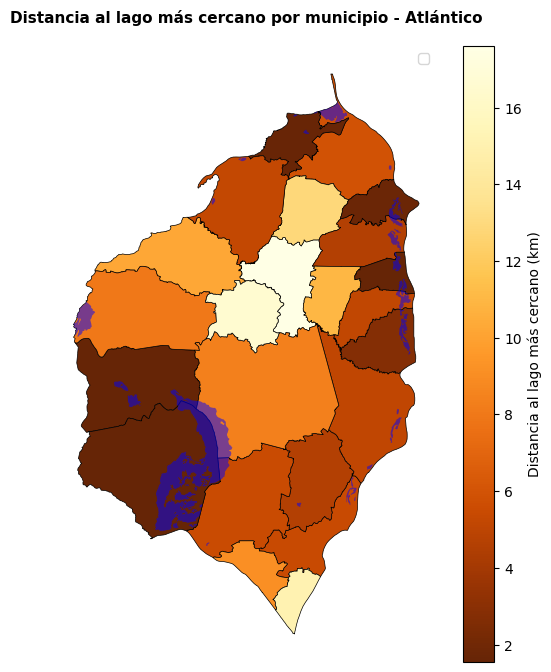

In [75]:
municipios_utm = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_lago.shp").to_crs(3116)
lagos_utm = gpd.read_file(r"C:\Dengue\Datos Clima\HydroLAKES_Atlantico.shp").to_crs(3116)

# ------------------------------------------------------------
# 5️⃣ Visualización
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 8))
municipios_utm.plot(
    column="dist_lag_1",
    cmap="YlOrBr_r",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Distancia al lago más cercano (km)"},
    ax=ax
)
lagos_utm.plot(ax=ax, color="blue", alpha=0.5, label="Lagos y embalses")

ax.set_title("Distancia al lago más cercano por municipio - Atlántico", fontsize=11, weight="bold")
ax.axis("off")
ax.legend()
plt.show()

In [76]:
import pandas as pd
import geopandas as gpd

# --- 1️⃣ Leer los CSV climáticos ---
df_tmax = pd.read_csv("resultados/temp_max_anual.csv")
df_tmin = pd.read_csv("resultados/temp_min_anual.csv")
df_humedad = pd.read_csv("resultados/humedad_anual.csv")
df_prec = pd.read_csv("resultados/precipitacion_anual.csv")

# --- 2️⃣ Unir todos los datos por municipio y año ---
df_final = (
    df_tmax
    .merge(df_tmin, on=["municipio", "año"], how="outer")
    .merge(df_humedad, on=["municipio", "año"], how="outer")
    .merge(df_prec, on=["municipio", "año"], how="outer")
)

# --- 3️⃣ Agregar la distancia al río (dato fijo por municipio) ---
gdf_rio = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_rio.shp")
gdf_rio = gdf_rio[["mpio_cnmbr", "dist_rio_1"]].rename(columns={"mpio_cnmbr": "municipio"})

gdf_lago = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_lago.shp")
gdf_lago = gdf_lago[["mpio_cnmbr", "dist_lag_1"]].rename(columns={"mpio_cnmbr": "municipio"})


# Normalizar nombres (por si hay tildes o mayúsculas)
df_final["municipio"] = df_final["municipio"].str.strip().str.upper()
gdf_rio["municipio"] = gdf_rio["municipio"].str.strip().str.upper()
gdf_lago["municipio"] = gdf_lago["municipio"].str.strip().str.upper()


# Merge con la distancia
df_final = df_final.merge(gdf_rio, on="municipio", how="left")
df_final = df_final.merge(gdf_lago, on="municipio", how="left")

# --- 4️⃣ Guardar CSV final ---
df_final.to_csv("resultados/datos_climaticos_completos.csv", index=False, encoding="utf-8-sig")

print("✅ Archivo final generado: resultados/datos_climaticos_completos.csv")
df_final.head()


✅ Archivo final generado: resultados/datos_climaticos_completos.csv


,municipio,año,temp_max,temp_min,humedad,precipitacion,dist_rio_1,dist_lag_1
0,BARANOA,2017,30.448818,23.998936,91.041267,550048.439013,1.275987,17.603675
1,BARANOA,2018,30.370150,23.930357,90.869202,469218.278412,1.275987,17.603675
2,BARANOA,2019,30.610964,24.197859,90.464691,434414.467096,1.275987,17.603675
3,BARANOA,2020,30.321980,24.007429,90.616714,546243.935162,1.275987,17.603675
4,BARANOA,2021,30.161251,23.827612,90.452652,547501.413585,1.275987,17.603675
